In [1]:
import pandas as pd 


Billet_data = pd.read_csv("data/billets.csv",
                          sep=";")

In [2]:
Billet_data.head(10)

print("Nombre de lignes :", Billet_data.shape[0])
print("Nombre de colonnes :", Billet_data.shape[1])

Billet_data = Billet_data.dropna()

print(Billet_data.info())
print(Billet_data.isnull().sum())


Nombre de lignes : 1500
Nombre de colonnes : 7
<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1463 non-null   bool   
 1   diagonal      1463 non-null   float64
 2   height_left   1463 non-null   float64
 3   height_right  1463 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1463 non-null   float64
 6   length        1463 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 81.4 KB
None
is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64


In [3]:
print(Billet_data.describe())

          diagonal  height_left  height_right   margin_low    margin_up  \
count  1463.000000  1463.000000   1463.000000  1463.000000  1463.000000   
mean    171.959193   104.031333    103.921476     4.485967     3.153083   
std       0.305457     0.299605      0.324181     0.663813     0.231466   
min     171.040000   103.140000    102.910000     2.980000     2.270000   
25%     171.750000   103.825000    103.710000     4.015000     2.990000   
50%     171.960000   104.040000    103.920000     4.310000     3.140000   
75%     172.170000   104.230000    104.150000     4.870000     3.315000   
max     173.010000   104.880000    104.950000     6.900000     3.910000   

            length  
count  1463.000000  
mean    112.674757  
std       0.873222  
min     109.490000  
25%     112.020000  
50%     112.960000  
75%     113.340000  
max     114.320000  


In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns

print(Billet_data["is_genuine"].value_counts())


is_genuine
True     971
False    492
Name: count, dtype: int64


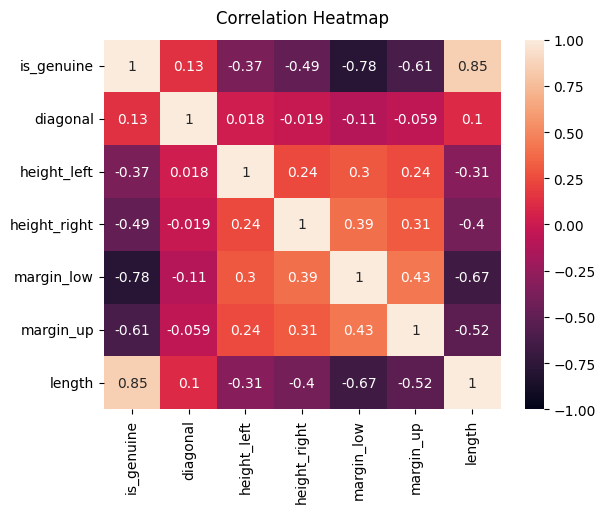

In [5]:
heatmap = sns.heatmap(Billet_data.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

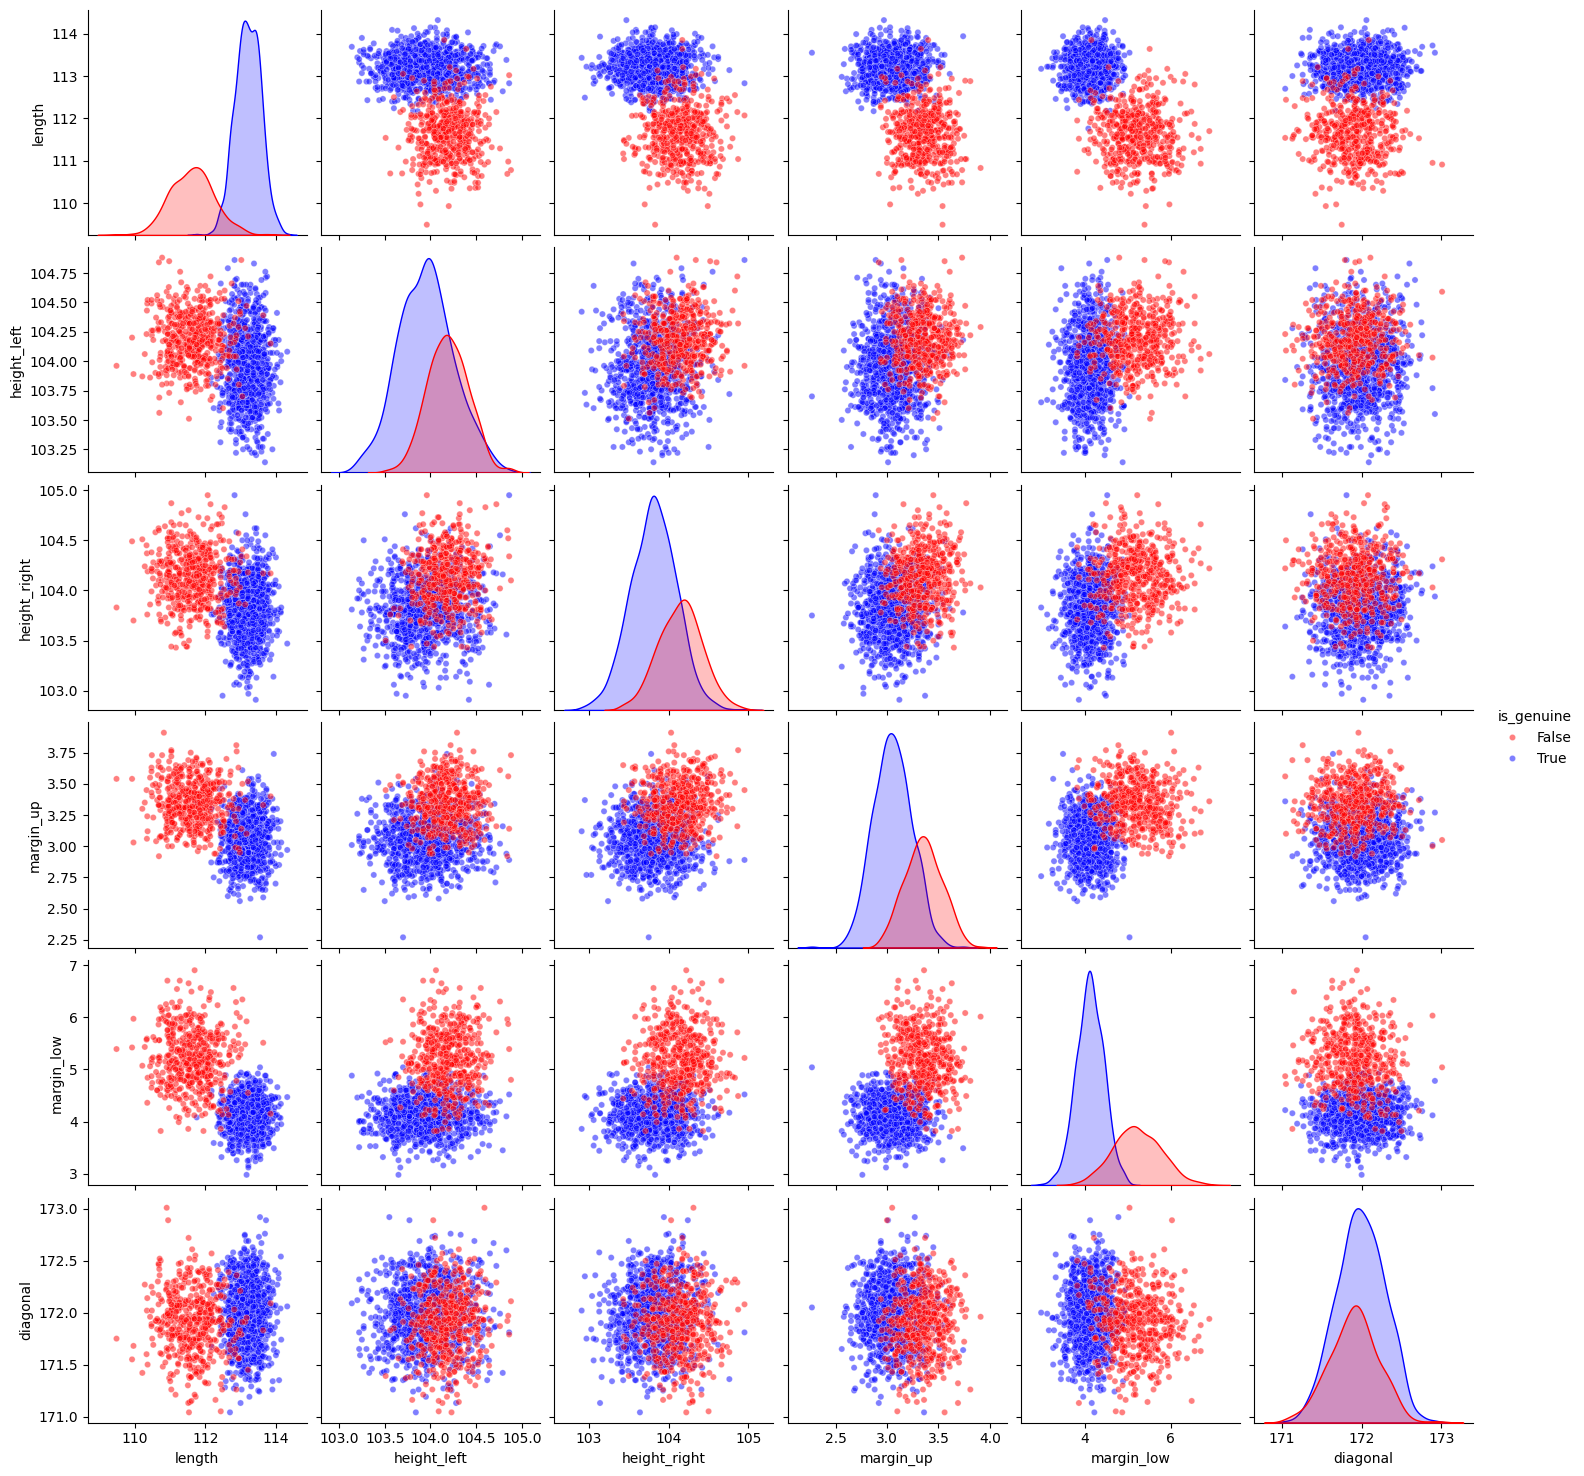

In [6]:
variables = [
    "length",
    "height_left",
    "height_right",
    "margin_up",
    "margin_low",
    "diagonal"
]

sns.pairplot(
    Billet_data,
    vars=variables,
    hue="is_genuine",
    palette={
        False: "red",
        True: "blue"
    },
    plot_kws={
        "alpha": 0.5,
        "s": 20
    }
)

plt.show()

In [7]:
X = Billet_data.drop(columns=["is_genuine"])

# Variable à prédire
y = Billet_data["is_genuine"]

y = Billet_data["is_genuine"].astype(int)

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

iteration_choisie = 2

for i, (train_index, test_index) in enumerate(skf.split(X, y), start=1):

    if i == iteration_choisie:

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print(f"Itération {i} sélectionnée")
        print("Train :", len(X_train))
        print("Test :", len(X_test))

        break

Itération 2 sélectionnée
Train : 1170
Test : 293


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Liste pour stocker les résultats
scores = []

# 5 itérations
for i in range(1, 6):

    # 1. Création du modèle
    modele_logistique = LogisticRegression(
        random_state=i,
        max_iter=1000
    )

    # 2. Entraînement
    modele_logistique.fit(X_train_scaled, y_train)

    # 3. Prédiction
    y_pred = modele_logistique.predict(X_test_scaled)

    # 4. Évaluation
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)

    print(f"Itération {i} : {accuracy:.3f}")

# Accuracy moyenne
print("\nAccuracy moyenne :", np.mean(scores))

NameError: name 'scores' is not defined

In [ ]:
y_pred = modele_logistique.predict(X_test_scaled)

# Probabilité d'appartenir à 1 True
y_prob = modele_logistique.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import recall_score

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print((y_test == False).sum())

predictions_reg = modele_logistique.predict(X_test_scaled)


recall_faux = recall_score(
    y_test,
    predictions_reg,
    pos_label=False
)

print("Pourcentage de faux billets détectés :", recall_faux * 100, "%")


Accuracy : 0.9965870307167235

Matrice de confusion :
[[ 99   0]
 [  1 193]]
99
Pourcentage de faux billets détectés : 100.0 %


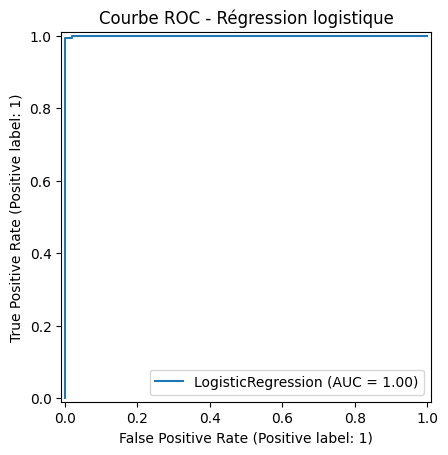

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    modele_logistique,
    X_test_scaled,
    y_test
)

plt.title("Courbe ROC - Régression logistique")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Analyse des données entrainé, avec 2 centroides 
KBillet = KMeans(n_clusters=2, random_state=17, n_init=10)
KBillet.fit(X_train_scaled)

predictions_k = KBillet.predict(X_test_scaled)

predictions_k = 1 - predictions_k
centroides = KBillet.cluster_centers_

print(centroides)

[[ 0.10613868 -0.2740699  -0.34744127 -0.54591452 -0.42647361  0.59748127]
 [-0.21309591  0.55025345  0.69756203  1.09603919  0.85623621 -1.19957036]]


In [ ]:
accuracy_k =  accuracy_score(y_test, predictions_k)

print("Accuracy :", accuracy_k)

print(confusion_matrix(y_test, predictions_k))

recall_faux = recall_score(
    y_test,
    predictions_k,
    pos_label=False
)

print("Pourcentage de faux billets détectés :", recall_faux * 100, "%")

Accuracy : 0.9897610921501706
[[ 98   1]
 [  2 192]]
Pourcentage de faux billets détectés : 98.98989898989899 %


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

predictions_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, predictions_knn)

print("Accuracy :", accuracy_knn)
print(confusion_matrix(y_test, predictions_knn))



recall_faux = recall_score(
    y_test,
    predictions_knn,
    pos_label=False
)

print("Pourcentage de faux billets détectés :", recall_faux * 100, "%")

Accuracy : 0.9897610921501706
[[ 97   2]
 [  1 193]]
Pourcentage de faux billets détectés : 97.97979797979798 %


In [ ]:
from sklearn.ensemble import RandomForestClassifier



RF = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

RF.fit(X_train_scaled, y_train)

predictions_rf = RF.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, predictions_rf)

print("Accuracy :", accuracy_rf)
print(confusion_matrix(y_test, predictions_rf))

recall_faux = recall_score(
    y_test,
    predictions_rf,
    pos_label=False
)

print("Pourcentage de faux billets détectés :", recall_faux * 100, "%")

Accuracy : 0.9931740614334471
[[ 99   0]
 [  2 192]]
Pourcentage de faux billets détectés : 100.0 %


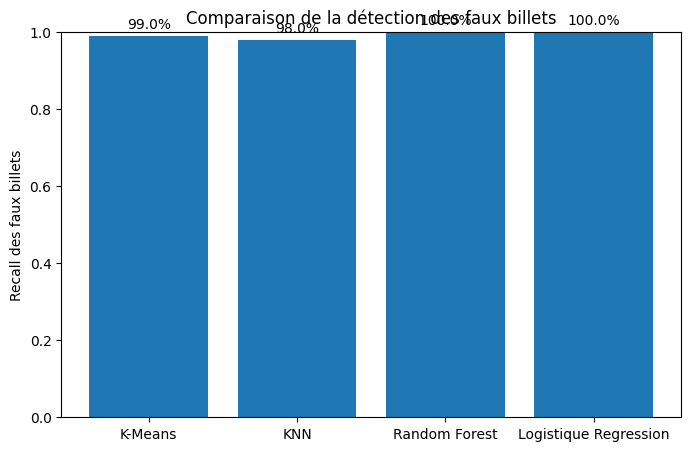

In [ ]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

# Recall de la classe Faux
recall_kmeans = recall_score(y_test, predictions_k, pos_label=False)
recall_knn = recall_score(y_test, predictions_knn, pos_label=False)
recall_rf = recall_score(y_test, predictions_rf, pos_label=False)
recall_reg = recall_score(y_test, predictions_reg, pos_label=False)

modeles = ["K-Means", "KNN", "Random Forest", "Logistique Regression"]
recalls = [recall_kmeans, recall_knn, recall_rf, recall_reg]

plt.figure(figsize=(8, 5))

bars = plt.bar(modeles, recalls)

plt.ylim(0, 1)
plt.ylabel("Recall des faux billets")
plt.title("Comparaison de la détection des faux billets")

# Afficher le % au-dessus des barres
for bar, score in zip(bars, recalls):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{score:.1%}",
        ha="center"
    )

plt.show()

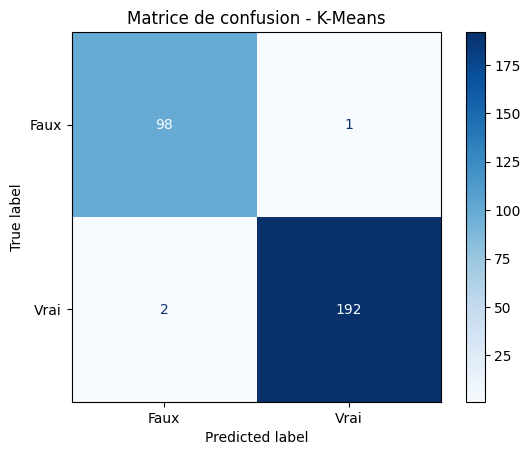

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_k,
    display_labels=["Faux", "Vrai"],
    cmap="Blues"
)

plt.title("Matrice de confusion - K-Means")
plt.show()

In [ ]:
import joblib

joblib.dump(RF, "random_forest_billets.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']